In [2]:
import pandas as pd


In [5]:

#carico dataset merged_adm1_wide.parquet
df = pd.read_parquet("../../data/merged/merged_adm1_wide.parquet")
df

,Country,location_name_full,Level 1,Area,adm1_pcode,adm2_pcode,From,To,Validity period,Date of analysis,...,gdelt_verbal_coop_tone,gdelt_material_coop_events,gdelt_material_coop_mentions,gdelt_material_coop_tone,gdelt_verbal_conflict_events,gdelt_verbal_conflict_mentions,gdelt_verbal_conflict_tone,gdelt_material_conflict_events,gdelt_material_conflict_mentions,gdelt_material_conflict_tone
0,AFG,Afghanistan,Kabul,None,AF01,,2017-08-01,2017-11-30 23:59:59,current,2017-08-01T00:00:00,...,-2.391549,6228.0,34053.0,-3.335023,8278.0,47734.0,-4.895209,13942.0,91166.0,-6.719388
1,AFG,Afghanistan,Kabul,None,AF01,,2018-08-01,2018-10-31 23:59:59,current,2018-08-01T00:00:00,...,-2.347104,3932.0,22156.0,-3.595366,5194.0,31849.0,-5.099749,10149.0,67189.0,-6.445504
2,AFG,Afghanistan,Kabul,None,AF01,,2018-11-01,2019-02-28 23:59:59,first projection,2018-11-01T00:00:00,...,-1.569367,6144.0,33598.0,-3.028408,7958.0,45917.0,-3.980824,10838.0,70564.0,-6.438398
3,AFG,Afghanistan,Kabul,None,AF01,,2019-08-01,2019-10-31 23:59:59,current,2019-08-01T00:00:00,...,-2.526242,4653.0,26735.0,-3.212505,7279.0,41200.0,-4.360610,10481.0,64091.0,-5.635617
4,AFG,Afghanistan,Kabul,None,AF01,,2019-11-01,2020-03-31 23:59:59,first projection,2019-11-01T00:00:00,...,-2.124733,8939.0,48517.0,-2.820670,8613.0,46929.0,-3.467968,10706.0,61631.0,-5.146167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10019,ZWE,Zimbabwe,Masvingo,None,ZW18,,2019-06-01,2019-09-30 23:59:59,current,2019-06-01T00:00:00,...,-1.661450,390.0,2041.0,-1.729670,713.0,3780.0,-3.642161,459.0,2506.0,-4.719800
10020,ZWE,Zimbabwe,Masvingo,None,ZW18,,2019-10-01,2019-12-31 23:59:59,first projection,2019-10-01T00:00:00,...,-1.139974,339.0,1867.0,-1.902814,455.0,2562.0,-3.109481,372.0,1866.0,-4.177619
10021,ZWE,Zimbabwe,Masvingo,None,ZW18,,2020-02-01,2020-06-30 23:59:59,current,2020-02-01T00:00:00,...,-1.743440,698.0,3802.0,-1.614034,814.0,4467.0,-3.357042,676.0,3439.0,-4.882919
10022,ZWE,Zimbabwe,Masvingo,None,ZW18,,2020-10-01,2020-12-31 23:59:59,current,2020-10-01T00:00:00,...,-0.543956,240.0,1348.0,-0.123948,280.0,1469.0,-2.400386,204.0,987.0,-3.927138


In [6]:
# 1.1 Andamento nel tempo
#Stacked area chart: proporzioni delle fasi 3, 4, 5 nel tempo, aggregato su tutti i paesi.

#Line chart: media di phase_3plus_percentage nel temp aggregata per paese

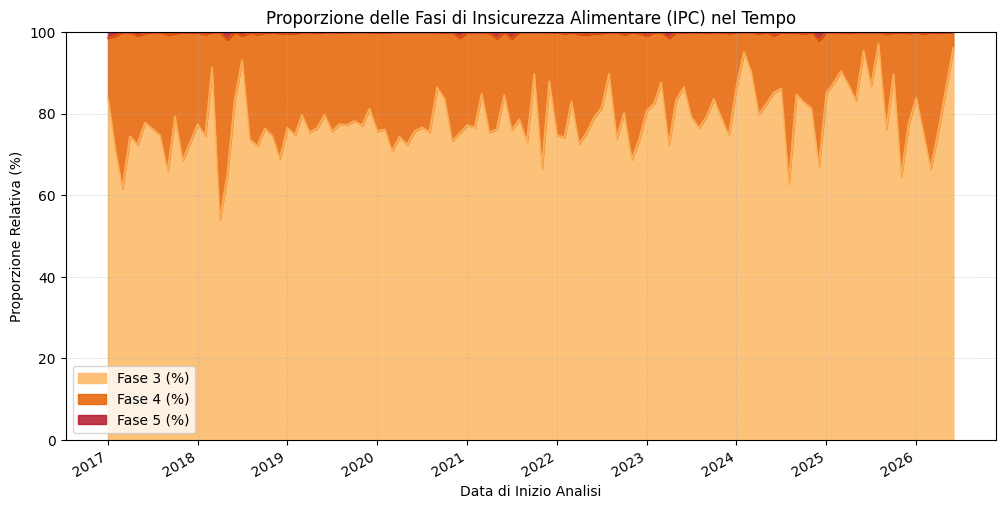

In [10]:
#Stacked area chart: proporzioni delle fasi 3, 4, 5 nel tempo, aggregato su tutti i paesi.

import matplotlib.pyplot as plt

# 1. Forza la conversione della colonna temporale e normalizza il timestamp
df["From"] = pd.to_datetime(df["From"])
df["date_grouped"] = df["From"].dt.to_period("M").dt.to_timestamp()

# 2. Aggrega i dati nel tempo sommando i valori assoluti di tutti i paesi
df_time = (
    df.groupby("date_grouped")[
        ["phase_3_number", "phase_4_number", "phase_5_number"]
    ]
    .sum()
    .reset_index()
)

# 3. Calcola il totale complessivo delle tre fasi per determinare le proporzioni
total_vulnerable = (
    df_time["phase_3_number"]
    + df_time["phase_4_number"]
    + df_time["phase_5_number"]
)

# 4. Converti i valori assoluti in proporzioni percentuali relative
df_time["Fase 3 (%)"] = (df_time["phase_3_number"] / total_vulnerable) * 100
df_time["Fase 4 (%)"] = (df_time["phase_4_number"] / total_vulnerable) * 100
df_time["Fase 5 (%)"] = (df_time["phase_5_number"] / total_vulnerable) * 100

# 5. Imposta l'indice temporale per il plotting
df_plot = df_time.set_index("date_grouped")[
    ["Fase 3 (%)", "Fase 4 (%)", "Fase 5 (%)"]
]

# 6. Genera lo Stacked Area Chart con palette colore coerente al rischio (es. scala arancione/rosso)
ax = df_plot.plot.area(
    figsize=(12, 6), color=["#fdb863", "#e66101", "#b2182b"], alpha=0.85
)

plt.title("Proporzione delle Fasi di Insicurezza Alimentare (IPC) nel Tempo")
plt.ylabel("Proporzione Relativa (%)")
plt.xlabel("Data di Inizio Analisi")
plt.ylim(0, 100)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left")
plt.show()